### Polynomial Regression Implementation

In [ ]:
## import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'y dataset')

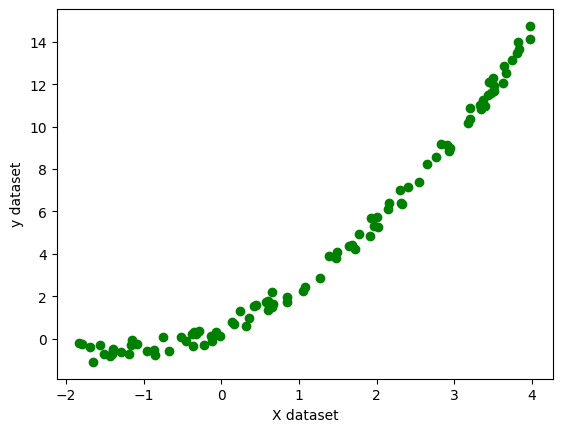

In [4]:
x = 6 * np.random.rand(100, 1)-2
y = 0.5 * x**2 + 1.5*x + np.random.rand(100,1)
## Quad eqn used y = 0.5x^2+1.5+2+outliers
plt.scatter(x,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('y dataset')

## Train Test Split

In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

### Implement Simple Linear Regression

In [8]:
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()

In [9]:
x_train

array([[ 3.64215537],
       [-0.74776905],
       [-1.82895079],
       [ 1.92201468],
       [ 3.39467577],
       [-1.40968794],
       [-0.5235887 ],
       [ 0.16519173],
       [-0.12947824],
       [ 0.66877518],
       [-1.09346411],
       [ 1.99945602],
       [ 2.40494532],
       [ 1.67703452],
       [ 0.44463894],
       [ 1.9060741 ],
       [ 0.30968528],
       [ 3.19997996],
       [ 3.81787641],
       [-0.35242775],
       [-0.36857303],
       [-1.69793265],
       [-0.11654642],
       [ 1.38833741],
       [ 3.46852158],
       [ 2.30166874],
       [ 2.31837544],
       [ 2.90517797],
       [ 3.32492136],
       [ 2.01759915],
       [ 3.63073195],
       [ 1.27131719],
       [ 3.80608953],
       [ 0.5680976 ],
       [-0.0696341 ],
       [ 0.65255785],
       [ 3.48747978],
       [ 1.08043298],
       [ 3.33794092],
       [-1.43017309],
       [ 1.77522729],
       [ 0.59703849],
       [-1.79961212],
       [-0.28812063],
       [-1.1867727 ],
       [ 2

In [10]:
regression_1.fit(x_train, y_train )

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
from sklearn.metrics import  r2_score
score = r2_score(y_test, regression_1.predict(x_test))
print(score)

0.9383571584901291


Text(0, 0.5, 'Y')

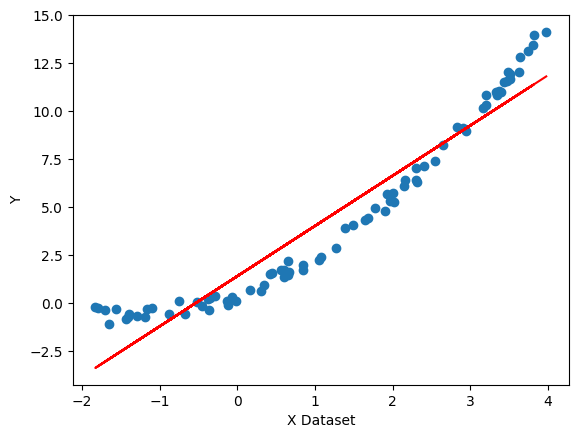

In [13]:
plt.plot(x_train, regression_1.predict(x_train), color='r')
plt.scatter(x_train, y_train)
plt.xlabel("X Dataset")
plt.ylabel("Y")

## Applying Polynomial Transformation

In [14]:
from sklearn.preprocessing import PolynomialFeatures

## Increasing it to degree =2 

In [15]:
poly = PolynomialFeatures(degree=2, include_bias=True)

In [17]:
X_train_poly = poly.fit_transform(x_train)
X_test_poly = poly.transform(x_test)

In [ ]:
X_train_poly # -> x, x^2 -> data is output

array([[ 1.00000000e+00,  3.64215537e+00,  1.32652958e+01],
       [ 1.00000000e+00, -7.47769047e-01,  5.59158547e-01],
       [ 1.00000000e+00, -1.82895079e+00,  3.34506099e+00],
       [ 1.00000000e+00,  1.92201468e+00,  3.69414045e+00],
       [ 1.00000000e+00,  3.39467577e+00,  1.15238236e+01],
       [ 1.00000000e+00, -1.40968794e+00,  1.98722008e+00],
       [ 1.00000000e+00, -5.23588701e-01,  2.74145127e-01],
       [ 1.00000000e+00,  1.65191734e-01,  2.72883090e-02],
       [ 1.00000000e+00, -1.29478236e-01,  1.67646135e-02],
       [ 1.00000000e+00,  6.68775180e-01,  4.47260241e-01],
       [ 1.00000000e+00, -1.09346411e+00,  1.19566376e+00],
       [ 1.00000000e+00,  1.99945602e+00,  3.99782439e+00],
       [ 1.00000000e+00,  2.40494532e+00,  5.78376199e+00],
       [ 1.00000000e+00,  1.67703452e+00,  2.81244480e+00],
       [ 1.00000000e+00,  4.44638940e-01,  1.97703787e-01],
       [ 1.00000000e+00,  1.90607410e+00,  3.63311847e+00],
       [ 1.00000000e+00,  3.09685277e-01

In [20]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.9973798380308445


In [ ]:
print(regression.coef_) # 3 Features

[[0.         1.47792475 0.50667111]]


In [ ]:
print(regression.intercept_) # 1 Feature

[0.49714575]


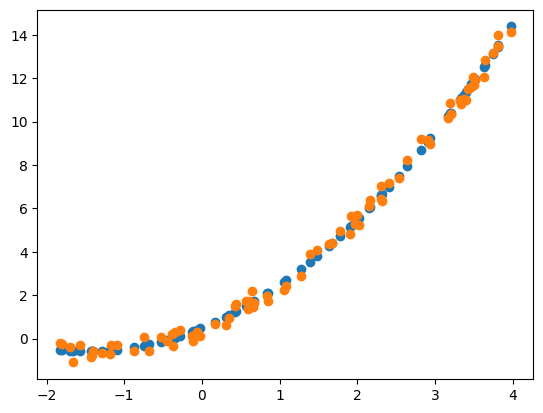

In [24]:
plt.scatter(x_train, regression.predict(X_train_poly))
plt.scatter(x_train,y_train)

### Increasing it to degree = 3

In [25]:
poly = PolynomialFeatures(degree=3, include_bias=True)
X_train_poly = poly.fit_transform(x_train)
X_test_poly = poly.transform(x_test)

In [ ]:
X_train_poly # 4 Feature -> x^3 is also included

array([[ 1.00000000e+00,  3.64215537e+00,  1.32652958e+01,
         4.83142682e+01],
       [ 1.00000000e+00, -7.47769047e-01,  5.59158547e-01,
        -4.18121454e-01],
       [ 1.00000000e+00, -1.82895079e+00,  3.34506099e+00,
        -6.11795194e+00],
       [ 1.00000000e+00,  1.92201468e+00,  3.69414045e+00,
         7.10019219e+00],
       [ 1.00000000e+00,  3.39467577e+00,  1.15238236e+01,
         3.91196446e+01],
       [ 1.00000000e+00, -1.40968794e+00,  1.98722008e+00,
        -2.80136018e+00],
       [ 1.00000000e+00, -5.23588701e-01,  2.74145127e-01,
        -1.43539291e-01],
       [ 1.00000000e+00,  1.65191734e-01,  2.72883090e-02,
         4.50780307e-03],
       [ 1.00000000e+00, -1.29478236e-01,  1.67646135e-02,
        -2.17065258e-03],
       [ 1.00000000e+00,  6.68775180e-01,  4.47260241e-01,
         2.99116548e-01],
       [ 1.00000000e+00, -1.09346411e+00,  1.19566376e+00,
        -1.30741541e+00],
       [ 1.00000000e+00,  1.99945602e+00,  3.99782439e+00,
      

In [27]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.9971742566540542


### Prediction of new data set

In [28]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

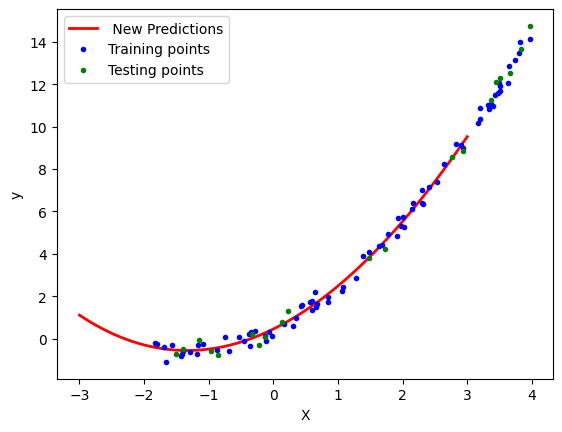

In [31]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
plt.plot(x_train, y_train, "b.", label='Training points')
plt.plot(x_test, y_test, "g.", label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Pipeline Concepts

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    lin_reg = LinearRegression()
    poly_features = PolynomialFeatures(degree=degree, include_bias=True)
    
    poly_regression = Pipeline([
        ("poly_features", poly_features),
        ("lin_reg", lin_reg)
    ])
    
    poly_regression.fit(x_train, y_train) # Create all the features using Polynomial Features function an then do a lin reg fit wrt to x_train and y_train.
    y_pred_new = poly_regression.predict(X_new)
    
    # plotting
    plt.plot(X_new, y_pred_new, 'r', label=f"Degree {degree}")
    plt.plot(x_train, y_train, "b.", linewidth=3)
    plt.plot(x_test, y_test, "g.", linewidth=3)
    
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4, 4, 0, 10])
    plt.show()

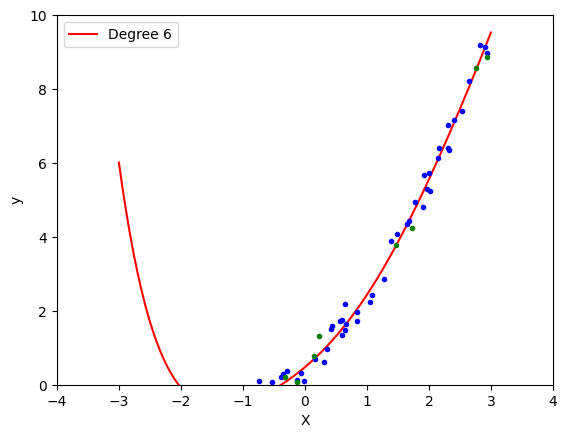

In [38]:
poly_regression(6)